Santiago Andrés Angulo Toro CC1001154362


## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



In [2]:
#Punto 1
torgersen = df[df["isla"] == "Torgersen"]

max_prof = torgersen["profundidad_pico (mm)"].max()
min_prof = torgersen["profundidad_pico (mm)"].min()

print("Profundidad máxima:", max_prof)
print("Profundidad mínima:", min_prof)

Profundidad máxima: 21.5
Profundidad mínima: 15.9


In [3]:
#Punto 2
indice = df["masa_corporal (g)"].astype(float).argmax()

pinguino_max = df.iloc[indice]

print(pinguino_max[["isla","especie","genero","masa_corporal (g)"]])

isla                 Biscoe
especie              Gentoo
genero                 Male
masa_corporal (g)    6300.0
Name: 231, dtype: object


In [4]:
#Punto 3
machos_no_gentoo = df[(df["genero"] == "Male") & (df["especie"] != "Gentoo")]

media_masa = machos_no_gentoo["masa_corporal (g)"].astype(float).mean()

print("Masa corporal media:", media_masa)

Masa corporal media: 4010.2803738317757


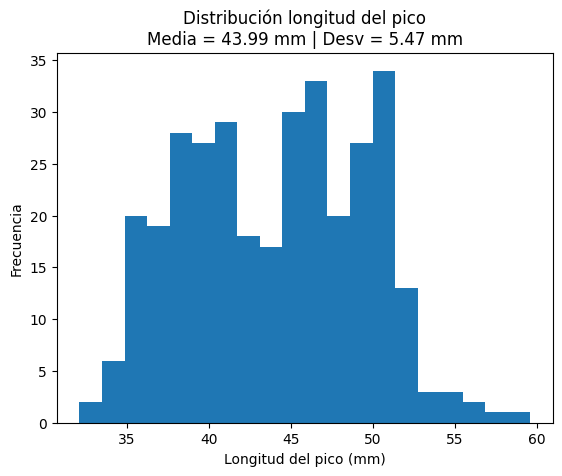

In [6]:
#Punto 4
import matplotlib.pyplot as plt

longitud = df["longitud_pico (mm)"].astype(float)

media = longitud.mean()
std = longitud.std()

########
plt.hist(longitud, bins=20)

plt.title(f"Distribución longitud del pico\nMedia = {media:.2f} mm | Desv = {std:.2f} mm")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Frecuencia")

plt.show()

Islas presentes:
isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64
Especies presentes:
especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


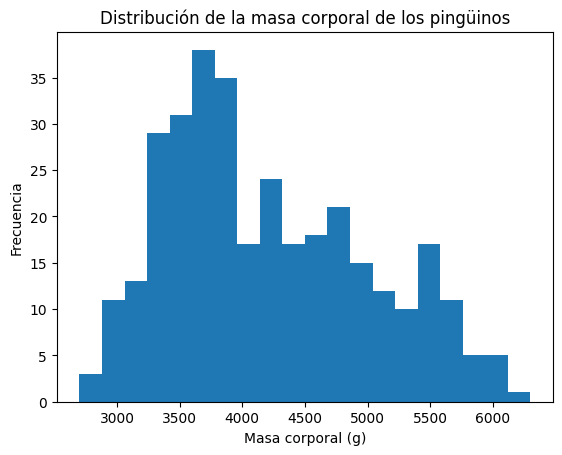

In [9]:
#Punto 5
print("Islas presentes:")
print(df["isla"].value_counts())

################
print("Especies presentes:")
print(df["especie"].value_counts())


############

import matplotlib.pyplot as plt

masa = df["masa_corporal (g)"].astype(float)

plt.hist(masa, bins=20)

plt.title("Distribución de la masa corporal de los pingüinos")
plt.xlabel("Masa corporal (g)")
plt.ylabel("Frecuencia")

plt.show()